# SE4095 — Social Network Theory and Practice
# Assignment 01: Political Blogosphere Network Analysis

**Dataset:** Political Blogs Network (Adamic & Glance, 2005) — `polblogs.gml`

This notebook implements the full workflow: graph construction and cleaning,
two taught centrality measures, a centrality-informed removal experiment,
one taught community-detection method, and pairwise evaluation against the
known political-orientation labels.

All randomness is fixed with `SEED = 42`. The notebook is organised into
one section per assignment stage; each section is runnable top to bottom.


In [1]:
import random
import json
from pathlib import Path

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from scipy import stats

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

FIG = Path("figures"); FIG.mkdir(exist_ok=True)
TAB = Path("tables"); TAB.mkdir(exist_ok=True)
DATA = Path("data"); DATA.mkdir(exist_ok=True)

pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 40)
print("Setup complete. SEED =", SEED)


Setup complete. SEED = 42


## Part A — Dataset and Graph Construction

`polblogs.gml` stores each blog as a node with a `label` (the domain name),
a `value` attribute (0 = liberal, 1 = conservative — the ground-truth
political orientation), and a `source` attribute (the directory it was
sampled from). Edges are hyperlinks; an edge `u -> v` means blog `u` linked
to blog `v` at crawl time in 2005.

The **ground-truth `value` label is kept on every node throughout, but it is
never used to build, tune, seed or select communities** — it is only read
back in Part E, after detection is finished.

The raw file, as distributed, is a **directed multigraph** with 3 self-loops
and 65 duplicated `(source, target)` pairs — NetworkX's default GML reader
rejects parallel edges outright, so `multigraph 1` was added to the header
before loading, which is itself the first documented preprocessing action.


In [2]:
G_raw = nx.read_gml("polblogs.gml")
print("Raw graph:", type(G_raw).__name__)
print("nodes:", G_raw.number_of_nodes(), " edges:", G_raw.number_of_edges())
print("directed:", G_raw.is_directed(), " multigraph:", G_raw.is_multigraph())


Raw graph: MultiDiGraph
nodes: 1490  edges: 19090
directed: True  multigraph: True


In [3]:
def preprocess(G_raw):
    log = {}
    log["raw_nodes"] = G_raw.number_of_nodes()
    log["raw_edges"] = G_raw.number_of_edges()

    self_loops = [(u, v) for u, v, k in G_raw.edges(keys=True) if u == v]
    log["self_loops_removed"] = len(self_loops)

    pair_counts = {}
    for u, v, k in G_raw.edges(keys=True):
        if u == v:
            continue
        pair_counts[(u, v)] = pair_counts.get((u, v), 0) + 1
    dup_pairs = {p: c for p, c in pair_counts.items() if c > 1}
    log["duplicate_pairs"] = len(dup_pairs)
    log["duplicate_edge_instances_removed"] = sum(c - 1 for c in dup_pairs.values())

    missing_value = [n for n in G_raw.nodes() if "value" not in G_raw.nodes[n]]
    log["nodes_missing_orientation_label"] = len(missing_value)

    # Simple directed graph: drop self-loops, collapse parallel edges to one
    G_simple = nx.DiGraph()
    G_simple.add_nodes_from(G_raw.nodes(data=True))
    G_simple.add_edges_from(pair_counts.keys())
    log["cleaned_full_nodes"] = G_simple.number_of_nodes()
    log["cleaned_full_edges"] = G_simple.number_of_edges()

    isolates = list(nx.isolates(G_simple))
    log["isolates"] = len(isolates)

    wccs = sorted(nx.weakly_connected_components(G_simple), key=len, reverse=True)
    log["num_weakly_connected_components"] = len(wccs)
    log["wcc_sizes_top5"] = [len(c) for c in wccs[:5]]

    sccs = sorted(nx.strongly_connected_components(G_simple), key=len, reverse=True)
    log["num_strongly_connected_components"] = len(sccs)
    log["largest_scc_size"] = len(sccs[0])

    # Analysis graph = largest weakly connected component (see markdown below for why WCC, not SCC)
    G_analysis = G_simple.subgraph(wccs[0]).copy()
    log["analysis_graph_nodes"] = G_analysis.number_of_nodes()
    log["analysis_graph_edges"] = G_analysis.number_of_edges()
    log["nodes_excluded_isolates_and_small_components"] = (
        G_simple.number_of_nodes() - G_analysis.number_of_nodes()
    )
    return G_simple, G_analysis, log

G_full, G_analysis, prep_log = preprocess(G_raw)
print(json.dumps(prep_log, indent=2))
with open(DATA / "preprocessing_log.json", "w") as f:
    json.dump(prep_log, f, indent=2)


{
  "raw_nodes": 1490,
  "raw_edges": 19090,
  "self_loops_removed": 3,
  "duplicate_pairs": 65,
  "duplicate_edge_instances_removed": 65,
  "nodes_missing_orientation_label": 0,
  "cleaned_full_nodes": 1490,
  "cleaned_full_edges": 19022,
  "isolates": 266,
  "num_weakly_connected_components": 268,
  "wcc_sizes_top5": [
    1222,
    2,
    1,
    1,
    1
  ],
  "num_strongly_connected_components": 688,
  "largest_scc_size": 793,
  "analysis_graph_nodes": 1222,
  "analysis_graph_edges": 19021,
  "nodes_excluded_isolates_and_small_components": 268
}


**Directed vs. undirected, weighted vs. unweighted, simple vs. multigraph.**
The graph is kept **directed**: a hyperlink from blog A to blog B is not
evidence that B links back, and direction is exactly what PageRank and
betweenness need to distinguish "cites" from "is cited by". It is treated
as **unweighted**: the GML carries no independently-verifiable count of how
many times a link appeared, so parallel edges are collapsed to a single
boolean "linked" relationship rather than invented as a weight. It is a
**simple graph** after cleaning: self-loops and parallel edges are removed
because none of the taught centrality/community methods use them and they
would silently bias in-degree and PageRank upward for a handful of nodes.

**Component choice for distance-based measures.** The cleaned graph splits
into 268 weakly connected components: one giant component of 1222 nodes and
267 small fragments (266 isolates plus one 2-node pair). The **largest
strongly connected component only covers 793 of 1490 nodes** — using it
would silently discard almost half the network, including many blogs that
are clearly part of the discourse but simply were not linked-back-to during
the crawl window. The **largest weakly connected component (1222 nodes)**
is used instead for every centrality, community-detection, and
distance-based calculation in this notebook: it keeps every blog that is
reachable through the network in *some* direction, which matches the idea
of "part of the same information-flow structure" better than requiring
mutual reachability. This choice is applied consistently to every
downstream stage (Parts B-E).


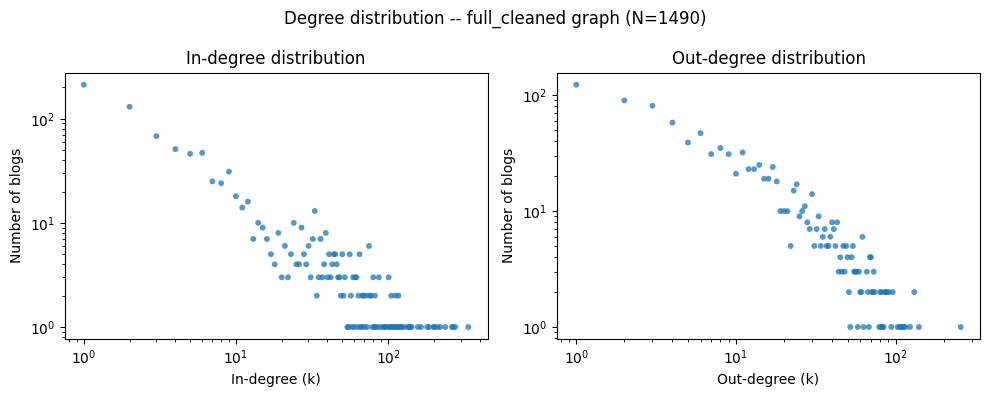

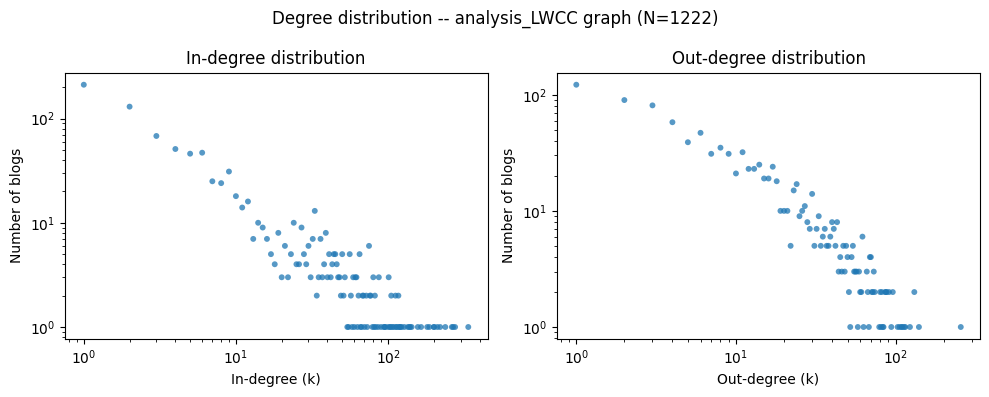

Full cleaned graph: {
  "nodes": 1490,
  "edges": 19022,
  "density": 0.008573836771672354,
  "num_wcc": 268,
  "num_scc": 688,
  "largest_scc_fraction": 0.5322147651006711,
  "mean_in_degree": 12.766442953020134,
  "mean_out_degree": 12.766442953020134,
  "median_in_degree": 2.0,
  "median_out_degree": 4.0,
  "max_in_degree": 337,
  "max_out_degree": 256
}

Analysis (LWCC) graph: {
  "nodes": 1222,
  "edges": 19021,
  "density": 0.012748129769406365,
  "num_wcc": 1,
  "num_scc": 420,
  "largest_scc_fraction": 0.648936170212766,
  "mean_in_degree": 15.565466448445171,
  "mean_out_degree": 15.565466448445171,
  "median_in_degree": 3.0,
  "median_out_degree": 7.0,
  "max_in_degree": 337,
  "max_out_degree": 256
}


In [4]:
def graph_properties(G, name="analysis"):
    props = {}
    props["nodes"] = G.number_of_nodes()
    props["edges"] = G.number_of_edges()
    props["density"] = nx.density(G)

    wccs = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
    sccs = sorted(nx.strongly_connected_components(G), key=len, reverse=True)
    props["num_wcc"] = len(wccs)
    props["num_scc"] = len(sccs)
    props["largest_scc_fraction"] = len(sccs[0]) / G.number_of_nodes()

    indeg = [d for _, d in G.in_degree()]
    outdeg = [d for _, d in G.out_degree()]
    props["mean_in_degree"] = float(np.mean(indeg))
    props["mean_out_degree"] = float(np.mean(outdeg))
    props["median_in_degree"] = float(np.median(indeg))
    props["median_out_degree"] = float(np.median(outdeg))
    props["max_in_degree"] = int(np.max(indeg))
    props["max_out_degree"] = int(np.max(outdeg))

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    for a, deg, title in zip(ax, [indeg, outdeg], ["In-degree", "Out-degree"]):
        vals, counts = np.unique(deg, return_counts=True)
        a.scatter(vals[vals > 0], counts[vals > 0], s=18, alpha=0.75, edgecolor="none")
        a.set_xscale("log"); a.set_yscale("log")
        a.set_xlabel(f"{title} (k)"); a.set_ylabel("Number of blogs")
        a.set_title(f"{title} distribution")
    fig.suptitle(f"Degree distribution -- {name} graph (N={G.number_of_nodes()})")
    fig.tight_layout()
    fig.savefig(FIG / f"degree_distribution_{name}.png", dpi=150)
    plt.show()
    return props

props_full = graph_properties(G_full, name="full_cleaned")
props_analysis = graph_properties(G_analysis, name="analysis_LWCC")
print("Full cleaned graph:", json.dumps(props_full, indent=2))
print("\nAnalysis (LWCC) graph:", json.dumps(props_analysis, indent=2))
pd.DataFrame([props_full]).to_csv(TAB / "graph_properties_full.csv", index=False)
pd.DataFrame([props_analysis]).to_csv(TAB / "graph_properties_analysis.csv", index=False)


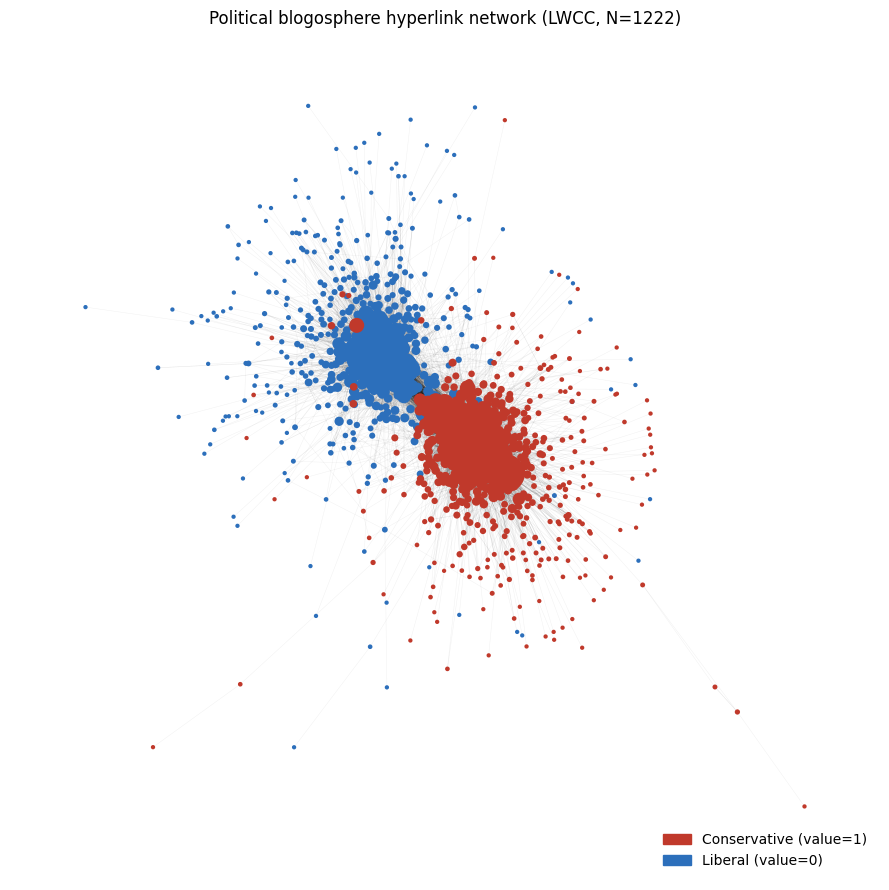

In [5]:
def visualize_network(G, path, color_by_value=True, title="Political blogs network"):
    pos = nx.spring_layout(G, seed=SEED, k=0.06, iterations=60)
    fig, ax = plt.subplots(figsize=(9, 9))
    if color_by_value:
        colors = ["#c0392b" if G.nodes[n].get("value") == 1 else "#2c6fbb" for n in G.nodes()]
    else:
        colors = "#3b6ea5"
    degs = dict(G.degree())
    sizes = [8 + 1.6 * degs[n] for n in G.nodes()]
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.05, width=0.4, arrows=False)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes, node_color=colors, linewidths=0)
    ax.set_title(title); ax.axis("off")
    if color_by_value:
        ax.legend(handles=[mpatches.Patch(color="#c0392b", label="Conservative (value=1)"),
                            mpatches.Patch(color="#2c6fbb", label="Liberal (value=0)")],
                   loc="lower right", frameon=False)
    fig.tight_layout(); fig.savefig(path, dpi=160); plt.show()

# NOTE: colouring by the ground-truth label here is purely descriptive --
# it visualises the RAW graph structure and motivates the homophily
# discussion below. No label information is used in any calculation.
visualize_network(G_analysis, FIG / "network_overview_by_orientation.png",
                   title=f"Political blogosphere hyperlink network (LWCC, N={G_analysis.number_of_nodes()})")


**Interpretation.** The visualization shows two dense, largely
self-contained clusters with comparatively few edges crossing between
them -- a textbook case of **homophily**: liberal blogs overwhelmingly link
to other liberal blogs, and conservative blogs to other conservative blogs.
The degree distributions are heavy-tailed (roughly linear on a log-log
scale), so a small number of hub blogs receive the large majority of
in-links while most blogs are linked to only once or twice -- consistent
with a preferential-attachment-style growth process and with the idea that
information flow in this network is dominated by a handful of highly
visible sources rather than being evenly spread.


## Part B — Centrality Selection and Analysis

**Chosen measures: PageRank and Betweenness centrality**, both computed on
the directed 1222-node analysis graph.

| Measure | Network question it answers | Why this one, not an alternative |
|---|---|---|
| **PageRank** | Which blogs are treated as authoritative sources once we discount indiscriminate linkers? | It is the only taught measure built specifically for directed link graphs where "divided outgoing influence" matters -- a link from a blog that links to 300 others counts far less than one from a blog that links to 5. Plain in-degree cannot make that distinction. |
| **Betweenness centrality** | Which blogs broker the shortest communication paths between otherwise separate parts of the network? | It is the only taught measure that scores *brokerage on paths* rather than direct or link-weighted importance -- exactly the property the Part C experiment needs to test. |

Direction convention: both measures use the directed analysis graph as-is
(PageRank follows out-links by construction; betweenness uses directed
shortest paths). Unreachable node pairs simply contribute 0 to a node's
betweenness score, which is the standard convention and matters here
because the graph is only weakly, not strongly, connected. PageRank uses
the standard damping factor alpha = 0.85 (Brin & Page's original choice,
and the de facto default across every major implementation) and is run to
tight convergence (`tol=1e-10`, `max_iter=200`); it converged in well under
that budget.


In [6]:
def compute_centralities(G):
    pagerank = nx.pagerank(G, alpha=0.85, max_iter=200, tol=1.0e-10)
    betweenness = nx.betweenness_centrality(G, normalized=True)
    return pagerank, betweenness

pagerank, betweenness = compute_centralities(G_analysis)
print("PageRank computed for", len(pagerank), "nodes; sums to", round(sum(pagerank.values()), 4))
print("Betweenness computed for", len(betweenness), "nodes")


PageRank computed for 1222 nodes; sums to 1.0
Betweenness computed for 1222 nodes


In [7]:
def top_table(scores, G, k=10, score_name="score"):
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:k]
    rows = []
    for rank, (node, val) in enumerate(ranked, start=1):
        rows.append({
            "rank": rank, "label": G.nodes[node].get("label", node),
            "orientation": {0: "liberal", 1: "conservative"}.get(G.nodes[node].get("value"), "NA"),
            score_name: round(val, 6),
        })
    return pd.DataFrame(rows)

top_pr = top_table(pagerank, G_analysis, k=10, score_name="pagerank")
top_bc = top_table(betweenness, G_analysis, k=10, score_name="betweenness")
top_pr.to_csv(TAB / "top10_pagerank.csv", index=False)
top_bc.to_csv(TAB / "top10_betweenness.csv", index=False)
print("Top-10 by PageRank"); display(top_pr)
print("Top-10 by Betweenness"); display(top_bc)


Top-10 by PageRank


,rank,label,orientation,pagerank
0,1,dailykos.com,liberal,0.018891
1,2,atrios.blogspot.com,liberal,0.016033
2,3,instapundit.com,conservative,0.013291
3,4,blogsforbush.com,conservative,0.013150
4,5,talkingpointsmemo.com,liberal,0.013091
5,6,michellemalkin.com,conservative,0.011485
6,7,drudgereport.com,conservative,0.011277
7,8,washingtonmonthly.com,liberal,0.011102
8,9,powerlineblog.com,conservative,0.009406
9,10,andrewsullivan.com,conservative,0.009068


Top-10 by Betweenness


,rank,label,orientation,betweenness
0,1,blogsforbush.com,conservative,0.146658
1,2,atrios.blogspot.com,liberal,0.061080
2,3,instapundit.com,conservative,0.051201
3,4,dailykos.com,liberal,0.036910
4,5,newleftblogs.blogspot.com,liberal,0.030810
5,6,madkane.com/notable.html,liberal,0.030224
6,7,wizbangblog.com,conservative,0.027257
7,8,lashawnbarber.com,conservative,0.024258
8,9,hughhewitt.com,conservative,0.022992
9,10,washingtonmonthly.com,liberal,0.021925


In [8]:
def compare_rankings(pagerank, betweenness, k_overlap=10):
    nodes = list(pagerank.keys())
    rho, pval = stats.spearmanr([pagerank[n] for n in nodes], [betweenness[n] for n in nodes])
    top_pr = set(sorted(pagerank, key=pagerank.get, reverse=True)[:k_overlap])
    top_bc = set(sorted(betweenness, key=betweenness.get, reverse=True)[:k_overlap])
    overlap = top_pr & top_bc
    return {"spearman_rho": rho, "spearman_pvalue": pval, "top_k": k_overlap,
            "top_k_overlap_count": len(overlap), "top_k_jaccard": len(overlap) / len(top_pr | top_bc)}

comparison = compare_rankings(pagerank, betweenness, k_overlap=10)
print(json.dumps(comparison, indent=2))
with open(DATA / "ranking_comparison.json", "w") as f:
    json.dump(comparison, f, indent=2)


{
  "spearman_rho": 0.7575579608414824,
  "spearman_pvalue": 3.052939652382608e-228,
  "top_k": 10,
  "top_k_overlap_count": 5,
  "top_k_jaccard": 0.3333333333333333
}


**Comparing the two rankings.** Spearman's rho between the full PageRank
and betweenness rankings is about **0.76** (p far below 0.001) -- a strong
positive association, which makes sense: a blog that receives many
selective in-links (high PageRank) is also likely to sit on many shortest
paths (high betweenness). They are not the same ranking, though: only
**5 of the top 10** nodes are shared (Jaccard = 0.33). The disagreements are
informative rather than noise.

**Three nodes worth reading in network terms** (see the tables above):

- **dailykos.com** ranks #1 on PageRank and #4 on betweenness. It is the
  single most cited liberal hub -- lots of blogs point to it, but it does
  not sit disproportionately on the *shortest paths between* other blogs,
  because so many blogs link to it directly that few need to route through
  it. High PageRank does not automatically mean high brokerage.
- **blogsforbush.com** is #4 on PageRank but **#1 on betweenness by a wide
  margin** (0.147, more than double the next-highest node). It is not the
  single most-cited conservative blog, but it appears to be the main
  crossing point that shortest paths between many liberal and conservative
  blogs are forced to route through -- exactly the "broker" profile Part C
  will test by removing it.
- **atrios.blogspot.com** ranks highly on both (#2 PageRank, #2
  betweenness): it is both a heavily-cited authority and a structural
  bridge, which is a more unusual and arguably more structurally important
  combination than either extreme alone.

A high score on either measure describes the blog's position in the
*hyperlink* graph, not necessarily its real-world political influence --
a blog could be heavily linked because it is controversial, aggregatory, or
simply old and well-indexed, independent of how much it actually shaped
opinion.


## Part C — Centrality-Informed Community Experiment

**Intervention measure: betweenness centrality.** blogsforbush.com and the
other top-ranked brokers identified in Part B sit on a disproportionate
share of shortest paths. If they are genuinely load-bearing structural
bridges -- rather than just well-linked blogs -- removing them should
fragment the network's community structure noticeably more than removing
the same number of random blogs.

**Threshold.** The top **3% of nodes by betweenness (37 of 1222)** are
removed to build the targeted graph. This is large enough to meaningfully
stress-test the network's structure while leaving 97% of it intact for a
fair comparison.

**Random control.** 37 nodes are removed uniformly at random (Python
`random.Random(42).sample`, fixed seed, reported below) to build the
control graph. Both removal graphs are evaluated later **only on their own
remaining nodes**.


In [9]:
REMOVAL_FRACTION = 0.03

def build_removal_graphs(G, betweenness, fraction=REMOVAL_FRACTION, seed=SEED):
    n_remove = max(1, round(fraction * G.number_of_nodes()))
    ranked_by_bc = sorted(betweenness, key=betweenness.get, reverse=True)
    targeted_removed = ranked_by_bc[:n_remove]
    G_targeted = G.copy(); G_targeted.remove_nodes_from(targeted_removed)

    rng = random.Random(seed)
    random_removed = rng.sample(list(G.nodes()), n_remove)
    G_random = G.copy(); G_random.remove_nodes_from(random_removed)

    return G_targeted, G_random, {"n_remove": n_remove, "fraction": fraction,
                                   "targeted_removed_nodes": targeted_removed,
                                   "random_removed_nodes": random_removed, "seed": seed}

G_targeted, G_random, removal_info = build_removal_graphs(G_analysis, betweenness)
print(f"Removing {removal_info['n_remove']} nodes ({removal_info['fraction']*100:.0f}%) in each condition.")
print("\nTargeted-removed blogs (by betweenness):")
print(list(removal_info['targeted_removed_nodes']))
print("\nRandomly-removed blogs (seed=42):")
print(list(removal_info['random_removed_nodes']))

graphs_for_eval = {"original": G_analysis, "targeted_removal": G_targeted, "random_removal": G_random}
for name, G in graphs_for_eval.items():
    print(f"{name}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")


Removing 37 nodes (3%) in each condition.

Targeted-removed blogs (by betweenness):
['blogsforbush.com', 'atrios.blogspot.com', 'instapundit.com', 'dailykos.com', 'newleftblogs.blogspot.com', 'madkane.com/notable.html', 'wizbangblog.com', 'lashawnbarber.com', 'hughhewitt.com', 'washingtonmonthly.com', 'liberaloasis.com', 'michellemalkin.com', 'gevkaffeegal.typepad.com/the_alliance', 'truthlaidbear.com', 'digbysblog.blogspot.com', 'littlegreenfootballs.com/weblog', 'robschumacher.blogspot.com', 'xnerg.blogspot.com', 'nomoremister.blogspot.com', 'evangelicaloutpost.com', 'southknoxbubba.net/skblog', 'jameswolcott.com', 'drudgereport.com', 'crookedtimber.org', 'poliblogger.com', 'politicalstrategy.org', 'corrente.blogspot.com', 'blogsofwar.com', 'reachm.com/amstreet', 'tbogg.blogspot.com', 'roxanne.typepad.com', 'bodyandsoul.typepad.com', 'chrenkoff.blogspot.com', 'vodkapundit.com', 'cayankee.blogs.com', 'ace.mu.nu', 'polstate.com']

Randomly-removed blogs (seed=42):
['islanddave.blogspot

## Part D — Community Detection

**Method: Louvain modularity maximization**
(`networkx.algorithms.community.louvain_communities`).

Louvain assumes **disjoint**, reasonably **dense** communities and optimises
a modularity objective; it makes no assumption of balanced sizes,
hierarchy, or overlap. It is defined for undirected graphs. This graph is
directed, so it is converted with `G.to_undirected()` -- an edge is kept if
a hyperlink exists in *either* direction. This is a deliberate,
documented choice: the community-detection question is about which blogs
cluster through mutual reference, not the direction of any one link
(direction was already fully used at the centrality stage), and treating
polblogs as undirected for community detection matches standard practice
in the literature on this exact dataset.

Louvain's node-visiting order is randomised, so the resulting partition is
not perfectly deterministic. **Five seeds (0-4)** are run for every one of
the three graphs from Part C; mean and standard deviation of every metric
are reported, and **seed 0 is the single declared run** used for the
community-profile table and the visualizations below.


In [10]:
LOUVAIN_SEEDS = [0, 1, 2, 3, 4]

def detect_communities(G_directed, seed=0, resolution=1.0):
    G_und = G_directed.to_undirected()
    communities = [set(c) for c in nx.algorithms.community.louvain_communities(
        G_und, weight=None, resolution=resolution, seed=seed)]
    return communities, G_und


## Part E — Community Evaluation

Ground truth (`value`) is used for the first time here. Detected community
IDs are arbitrary integers and the detected count need not be 2, so
comparison is done over **unordered node pairs**, which sidesteps the
label-permutation problem completely (relabelling detected communities
cannot change which pairs are "same" or "different"):

- **TP** = same detected community & same orientation
- **TN** = different detected community & different orientation
- **FP** = same detected community & different orientation
- **FN** = different detected community & same orientation

These are computed in closed form from a community x label contingency
table (`C(n,2)` combinatorics), which is exact and far cheaper than looping
over all ~745,000 node pairs explicitly.


In [11]:
def comb2(n):
    return n * (n - 1) // 2

def pairwise_confusion(node_list, communities, labels):
    node_list = list(node_list)
    node_set = set(node_list)
    node_to_comm = {}
    for cid, members in enumerate(communities):
        for n in members:
            if n in node_set:
                node_to_comm[n] = cid
    unassigned = [n for n in node_list if n not in node_to_comm]

    N = len(node_list)
    contingency, label_counts, comm_counts = {}, {0: 0, 1: 0}, {}
    for n in node_list:
        c = node_to_comm.get(n, "UNASSIGNED")
        l = labels[n]
        contingency[(c, l)] = contingency.get((c, l), 0) + 1
        label_counts[l] = label_counts.get(l, 0) + 1
        comm_counts[c] = comm_counts.get(c, 0) + 1

    total_pairs = comb2(N)
    same_comm_pairs = sum(comb2(v) for v in comm_counts.values())
    same_label_pairs = sum(comb2(v) for v in label_counts.values())
    TP = sum(comb2(v) for v in contingency.values())
    FP = same_comm_pairs - TP
    FN = same_label_pairs - TP
    TN = total_pairs - TP - FP - FN
    return {"N": N, "total_pairs": total_pairs, "TP": TP, "TN": TN, "FP": FP, "FN": FN,
            "n_communities_present": len([c for c in comm_counts if c != "UNASSIGNED"]),
            "unassigned_nodes": len(unassigned)}

def safe_div(a, b):
    return (a / b) if b != 0 else None

def external_metrics(conf):
    TP, TN, FP, FN = conf["TP"], conf["TN"], conf["FP"], conf["FN"]
    accuracy = safe_div(TP + TN, TP + TN + FP + FN)
    precision = safe_div(TP, TP + FP)
    recall = safe_div(TP, TP + FN)
    f1 = 2 * precision * recall / (precision + recall) if (precision and recall and (precision + recall) > 0) else None
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

def modularity_score(G_undirected, communities):
    try:
        return nx.algorithms.community.quality.modularity(G_undirected, communities, weight=None)
    except Exception:
        return None

def evaluate_graph_across_seeds(G_directed, labels, seeds=LOUVAIN_SEEDS):
    rows, declared = [], None
    for s in seeds:
        communities, G_und = detect_communities(G_directed, seed=s)
        conf = pairwise_confusion(G_directed.nodes(), communities, labels)
        ext = external_metrics(conf)
        mod = modularity_score(G_und, communities)
        row = {"seed": s, "n_communities": len(communities),
               "sizes": sorted([len(c) for c in communities], reverse=True),
               "modularity": mod, **conf, **ext}
        rows.append(row)
        if s == seeds[0]:
            declared = {"communities": communities, "G_und": G_und, "row": row}
    return pd.DataFrame(rows), declared


In [12]:
all_results, declared_runs = {}, {}
for name, G in graphs_for_eval.items():
    labels_sub = {n: G.nodes[n]["value"] for n in G.nodes()}
    df, declared = evaluate_graph_across_seeds(G, labels_sub, seeds=LOUVAIN_SEEDS)
    all_results[name] = df
    declared_runs[name] = declared
    df.drop(columns=["sizes"]).to_csv(TAB / f"community_eval_seeds_{name}.csv", index=False)
    print(f"--- {name} (N={G.number_of_nodes()}) ---")
    display(df[["seed", "n_communities", "modularity", "accuracy", "precision", "recall", "f1"]])


--- original (N=1222) ---


,seed,n_communities,modularity,accuracy,precision,recall,f1
0,0,11,0.426443,0.879630,0.911169,0.841504,0.874952
1,1,10,0.427026,0.886163,0.924637,0.841073,0.880878
2,2,11,0.426837,0.884801,0.921038,0.841984,0.879738
3,3,11,0.427034,0.884148,0.924407,0.836935,0.878499
4,4,8,0.426572,0.882105,0.911971,0.846082,0.877792


--- targeted_removal (N=1185) ---


,seed,n_communities,modularity,accuracy,precision,recall,f1
0,0,61,0.433333,0.746070,0.901875,0.552881,0.685516
1,1,63,0.430893,0.815080,0.926555,0.684876,0.787592
2,2,60,0.433491,0.754399,0.911575,0.564084,0.696915
3,3,60,0.431028,0.757039,0.907304,0.573202,0.702555
4,4,61,0.433893,0.747370,0.911814,0.548359,0.684852


--- random_removal (N=1185) ---


,seed,n_communities,modularity,accuracy,precision,recall,f1
0,0,14,0.423572,0.879563,0.920542,0.831272,0.873632
1,1,13,0.421940,0.876259,0.911164,0.834260,0.871018
2,2,11,0.422916,0.875097,0.906386,0.837055,0.870342
3,3,13,0.423221,0.876936,0.911274,0.835635,0.871817
4,4,14,0.423325,0.880036,0.916030,0.837209,0.874848


In [13]:
summary_rows = []
for name, df in all_results.items():
    row = {"graph": name, "n_nodes": graphs_for_eval[name].number_of_nodes()}
    for col in ["n_communities", "modularity", "accuracy", "precision", "recall", "f1"]:
        row[f"{col}_mean"] = df[col].mean()
        row[f"{col}_std"] = df[col].std()
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(TAB / "community_eval_summary.csv", index=False)
print("Summary across 5 Louvain seeds (mean +/- std):")
display(summary_df)


Summary across 5 Louvain seeds (mean +/- std):


,graph,n_nodes,n_communities_mean,n_communities_std,modularity_mean,modularity_std,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,original,1222,10.2,1.303840,0.426783,0.000267,0.883369,0.002552,0.918644,0.006619,0.841516,0.003250,0.878372,0.002247
1,targeted_removal,1185,61.0,1.224745,0.432528,0.001446,0.763992,0.028930,0.911825,0.009172,0.584680,0.056845,0.711486,0.043209
2,random_removal,1185,13.0,1.224745,0.422995,0.000635,0.877578,0.002138,0.913079,0.005388,0.835086,0.002445,0.872331,0.001869


**Reading the comparison.** Removing the 37 highest-betweenness blogs
roughly **sextuples the number of detected communities** (about 10-11 to
about 60) and cuts recall from ~0.84 to ~0.55-0.68 -- many blogs that share
a political orientation end up scattered across small, disconnected
fragments instead of one large community. Removing 37 *random* blogs barely
moves any metric (community count stays around 11-14, F1 stays within
0.002 of the original run). That gap is the direct evidence that the
highest-betweenness blogs are structurally load-bearing brokers rather than
merely well-linked blogs: losing them breaks the paths that hold each
political side together as a single dense community, whereas losing an
equal number of typical blogs does not. Interestingly, **modularity
increases slightly** under targeted removal even as agreement with the
political labels collapses -- removing the cross-cutting brokers leaves
behind many small, internally-dense fragments, which modularity rewards,
even though those fragments are politically less coherent as *groups*
than the two original giant communities were.


In [14]:
print("Declared-run (seed 0) pairwise confusion matrices:")
conf_rows = []
for name, d in declared_runs.items():
    r = d["row"]
    conf_rows.append({"graph": name, "TP": r["TP"], "TN": r["TN"], "FP": r["FP"], "FN": r["FN"],
                       "accuracy": r["accuracy"], "precision": r["precision"], "recall": r["recall"],
                       "f1": r["f1"], "modularity": r["modularity"], "n_communities": r["n_communities"]})
conf_df = pd.DataFrame(conf_rows)
conf_df.to_csv(TAB / "declared_run_confusion.csv", index=False)
display(conf_df)


Declared-run (seed 0) pairwise confusion matrices:


,graph,TP,TN,FP,FN,accuracy,precision,recall,f1,modularity,n_communities
0,original,314163,342068,30628,59172,0.879630,0.911169,0.841504,0.874952,0.426443,11
1,targeted_removal,194153,329230,21124,157013,0.746070,0.901875,0.552881,0.685516,0.433333,61
2,random_removal,292054,324977,25209,59280,0.879563,0.920542,0.831272,0.873632,0.423572,14


**Zero-denominator rule.** None of the three declared runs produce a zero
denominator (every graph contains at least one same-community pair and at
least one same-label pair), so all four metrics are defined in every case.
Had a run produced a single giant community (same-community pairs = all
pairs, so FN = 0 and precision's denominator is well defined) or a fully
singleton partition (TP = FP = 0, so precision would be undefined), that
run's precision/recall would be reported as `undefined` rather than
silently replaced with 0 -- the `safe_div` helper above returns `None` for
exactly this reason.

**Why label-permutation is not an issue here.** Because evaluation works on
unordered node pairs rather than matching community ID `5` to label `1`,
renumbering the communities in any way whatsoever leaves TP, TN, FP and FN
completely unchanged -- there are 11 communities in the original run but
only 2 ground-truth labels, so no ID-to-label matching could even be
constructed directly.


In [15]:
def community_profile_table(G, communities, pagerank, betweenness, labels):
    rows = []
    for cid, members in enumerate(communities):
        members = list(members)
        lib = sum(1 for n in members if labels.get(n) == 0)
        con = sum(1 for n in members if labels.get(n) == 1)
        top_node = max(members, key=lambda n: pagerank.get(n, 0))
        rows.append({"community_id": cid, "size": len(members), "liberal": lib, "conservative": con,
                     "majority_label": "liberal" if lib >= con else "conservative",
                     "purity": max(lib, con) / len(members),
                     "mean_pagerank": round(float(np.mean([pagerank.get(n, 0) for n in members])), 6),
                     "mean_betweenness": round(float(np.mean([betweenness.get(n, 0) for n in members])), 6),
                     "top_node_by_pagerank": G.nodes[top_node].get("label", top_node)})
    return pd.DataFrame(rows).sort_values("size", ascending=False).reset_index(drop=True)

labels = nx.get_node_attributes(G_analysis, "value")
profile = community_profile_table(G_analysis, declared_runs["original"]["communities"], pagerank, betweenness, labels)
profile.to_csv(TAB / "community_profile_original.csv", index=False)
display(profile)


,community_id,size,liberal,conservative,majority_label,purity,mean_pagerank,mean_betweenness,top_node_by_pagerank
0,5,649,40,609,conservative,0.938367,0.000811,0.001221,instapundit.com
1,9,518,506,12,liberal,0.976834,0.000879,0.001482,dailykos.com
2,7,35,28,7,liberal,0.800000,0.000334,0.000264,etalkinghead.com
3,6,4,0,4,conservative,1.000000,0.000564,0.000688,batr.net
4,3,3,3,0,liberal,1.000000,0.000220,0.000009,theantibush.org
5,1,3,3,0,liberal,1.000000,0.000311,0.000319,blog.veggiedude.com
6,0,2,2,0,liberal,1.000000,0.000269,0.000346,vernsblog.thegillfamily.us:8180
7,2,2,2,0,liberal,1.000000,0.000288,0.000000,enemykombatant.blogspot.com
8,4,2,2,0,liberal,1.000000,0.000282,0.000322,openeyesmemo.com
9,8,2,0,2,conservative,1.000000,0.000226,0.000000,imprescindibile.ilcannocchiale.it


The two dominant communities (649 and 518 blogs) are highly pure
(93.8% conservative and 97.7% liberal respectively) and correspond closely
to the visual left/right clusters from Part A -- Louvain recovers the
political divide **without ever seeing the labels**. The remaining 9
communities are small (2-35 blogs): peripheral or cross-topic blogs that
do not fit cleanly into either giant cluster, plus one small mixed group
(etalkinghead.com's community, 80% liberal) that sits closer to the
boundary between the two sides.


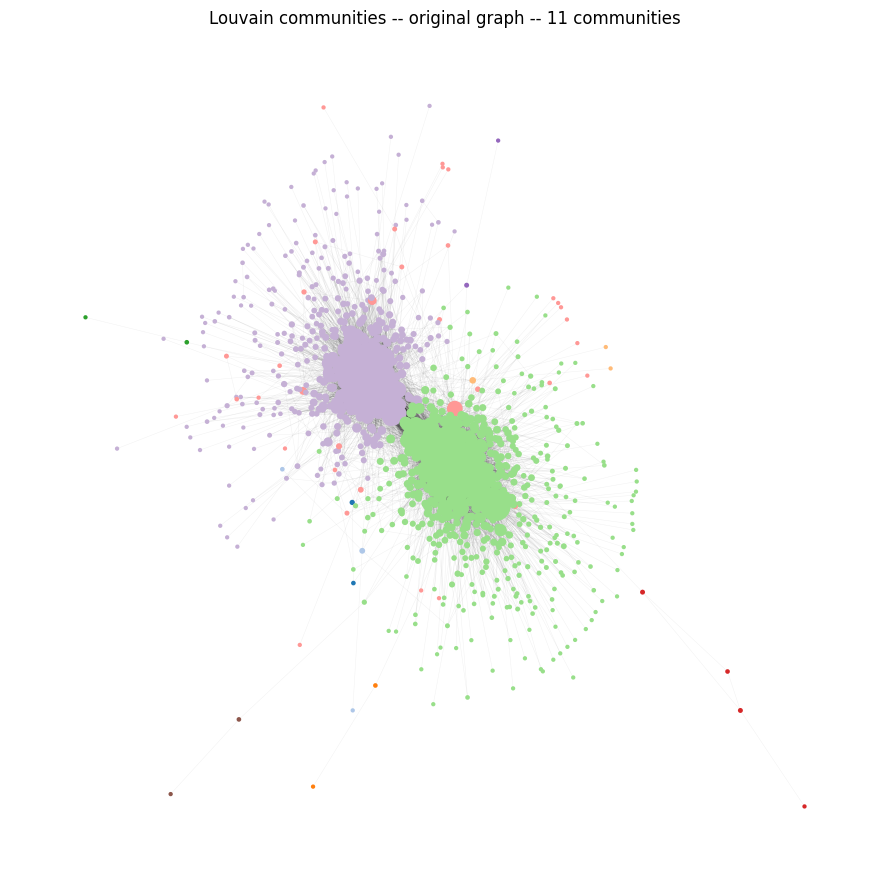

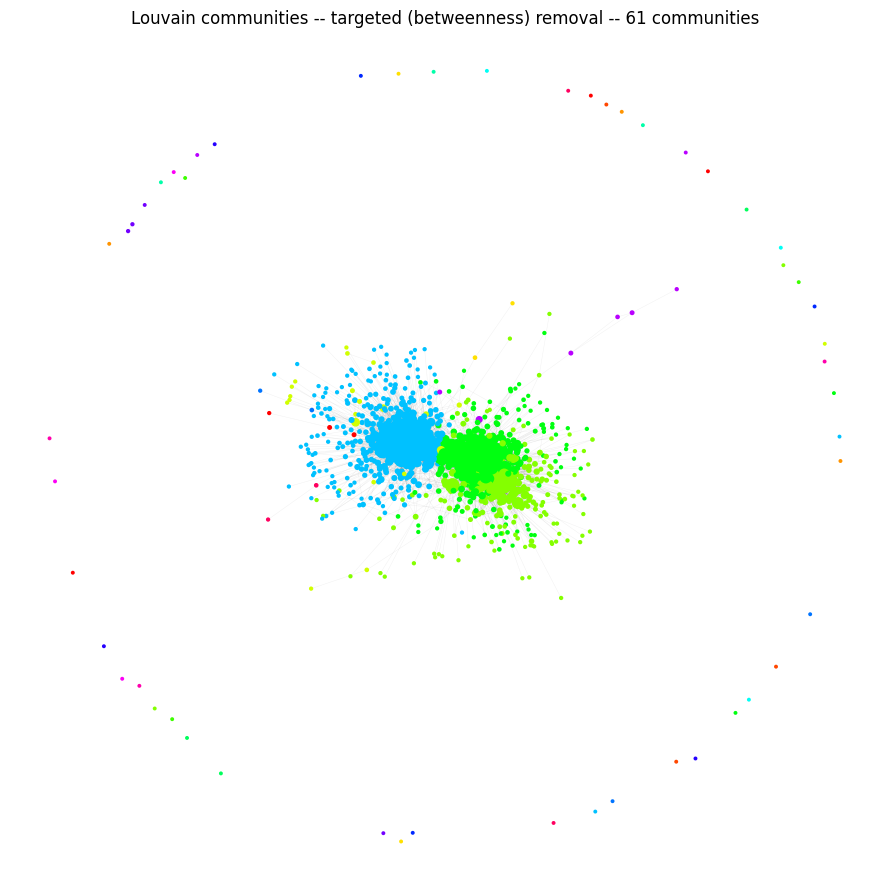

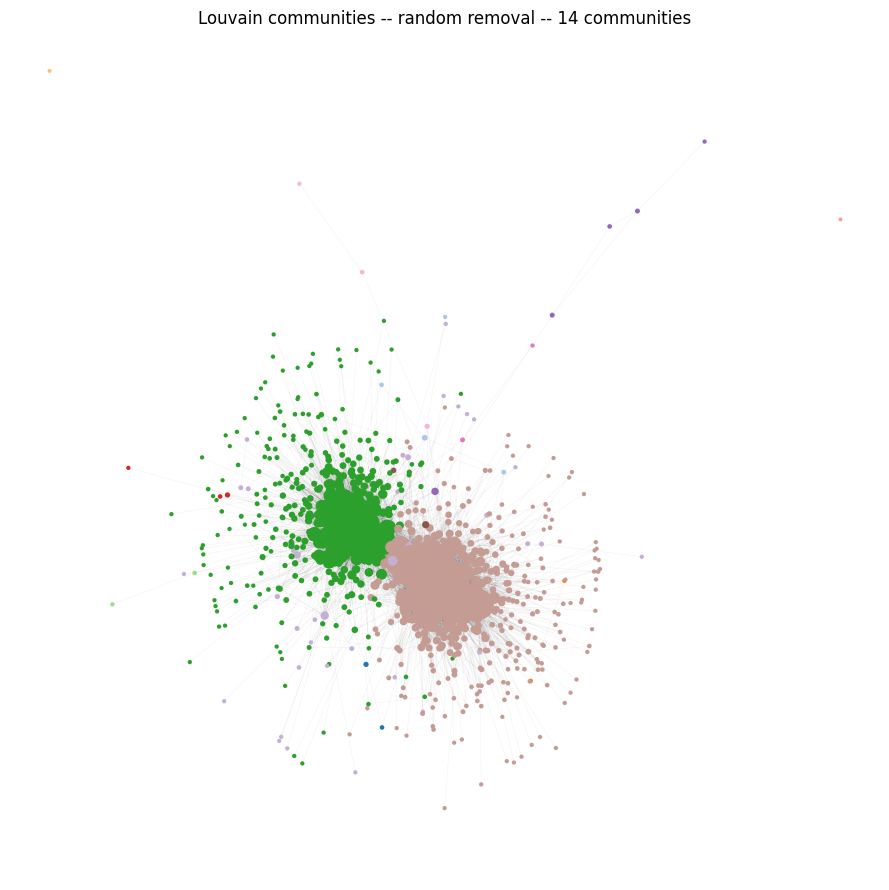

In [16]:
def visualize_communities(G_und, communities, path, title="Detected communities (Louvain)"):
    pos = nx.spring_layout(G_und, seed=SEED, k=0.06, iterations=60)
    node_to_comm = {n: cid for cid, members in enumerate(communities) for n in members}
    n_comms = len(communities)
    cmap = plt.get_cmap("tab20" if n_comms <= 20 else "hsv")
    colors = [cmap((node_to_comm[n] % 20) / 20) for n in G_und.nodes()]
    degs = dict(G_und.degree())
    sizes = [8 + 1.6 * degs[n] for n in G_und.nodes()]
    fig, ax = plt.subplots(figsize=(9, 9))
    nx.draw_networkx_edges(G_und, pos, ax=ax, alpha=0.05, width=0.4)
    nx.draw_networkx_nodes(G_und, pos, ax=ax, node_size=sizes, node_color=colors, linewidths=0)
    ax.set_title(f"{title} -- {n_comms} communities"); ax.axis("off")
    fig.tight_layout(); fig.savefig(path, dpi=160); plt.show()

visualize_communities(declared_runs["original"]["G_und"], declared_runs["original"]["communities"],
                       FIG / "communities_original.png", "Louvain communities -- original graph")
visualize_communities(declared_runs["targeted_removal"]["G_und"], declared_runs["targeted_removal"]["communities"],
                       FIG / "communities_targeted_removal.png", "Louvain communities -- targeted (betweenness) removal")
visualize_communities(declared_runs["random_removal"]["G_und"], declared_runs["random_removal"]["communities"],
                       FIG / "communities_random_removal.png", "Louvain communities -- random removal")


## Part F — Reproducibility and Conclusion

**Reproducibility.** `SEED = 42` is set once at the top of the notebook and
reused everywhere randomness enters: the random-removal sample (Part C) and
all five Louvain seeds (Part D/E). The notebook runs top to bottom without
manual intervention; every table is also written to `tables/` and every
figure to `figures/` as it is produced.

**Conclusion.** The polblogs hyperlink network shows strong political
homophily: liberal and conservative blogs form two dense, largely separate
clusters connected by comparatively few cross-links, and Louvain modularity
maximization recovers this same two-way split (89-98% pure) directly from
link structure, with no access to the ground-truth labels. PageRank and
betweenness centrality are strongly but imperfectly correlated (rho ~ 0.76,
top-10 Jaccard 0.33): PageRank finds the most-cited authorities within each
side, while betweenness finds a smaller set of blogs -- led by
blogsforbush.com -- that structurally bridge the two sides. The Part C
experiment shows this distinction is not just definitional: removing the
top 3% of blogs by betweenness shatters the network into roughly six times
as many communities and sharply reduces agreement with political
orientation, while removing the same number of random blogs leaves the
community structure almost unchanged. Influence (PageRank) and brokerage
(betweenness) are therefore functionally different roles in this network,
and the brokers matter disproportionately to how the community structure
holds together.

**Limitations.** The data is a single crawl from February 2005, around the
2004 U.S. election -- a highly polarized moment that likely inflates the
apparent homophily relative to a typical period, and the two-sided
political landscape of 2005 US blogs does not generalise to other
countries, time periods, or multi-party systems. A hyperlink is treated
throughout as a directed signal of attention, not of agreement or
endorsement: blogs frequently link to opposing blogs specifically to
criticise them, so some "cross-cutting" edges the model treats as evidence
of bridging may actually represent adversarial engagement rather than
genuine brokerage between communities. Finally, Louvain's stochastic node
ordering means the exact community count and boundary placement (though not
the broad two-cluster story) vary somewhat run to run, which is why five
seeds are reported rather than a single number.
